In [ ]:
# Local llm object
from langchain.chat_models import init_chat_model

llm = init_chat_model(
    model="qwen3:8b",
    model_provider="ollama",
    num_ctx=2048,
)

In [1]:
# API llm object
from pathlib import Path
from dotenv import load_dotenv
import os

from langchain.chat_models import init_chat_model
env_path = Path(".env")
if not env_path.exists():
    raise FileNotFoundError(".env file not found")

load_dotenv()

gemini_llm = init_chat_model(
    model="gemini-3.1-flash-lite",
    api_key=os.getenv("GEMINI_API_KEY"),
    model_provider="google_genai",
    max_tokens=2048,
    temperature=0.7,
)

# Prompts & Chains

In [2]:
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder

In [3]:
# Generation prompt
generation_prompt = ChatPromptTemplate.from_messages([
    (
        "system",
        "You are a professional LinkedIn content assisitant tasked with crafting engaging, insightful, and well-structured LinkedIn posts."
        " Generate the best LinkedIn post possible for the user's request."
        " If the user provides feedback or critique, respond with a refined version of your previous attempts, improving clarity, tone, or engagement as needed.",
    ),
    MessagesPlaceholder(variable_name="messages")
])

In [4]:
# Create Post generation chain
generation_chain = generation_prompt | gemini_llm

In [5]:
# Reflection prompt
reflection_prompt = ChatPromptTemplate.from_messages([
    (
        "system",
        """You are a professional LinkedIn content strategist and thought leadership expert. Your task is to critically evaluate the given LinkedIn post and provide a comprehensive critique. Follow these guidelines:

        1. Assess the post’s overall quality, professionalism, and alignment with LinkedIn best practices.
        2. Evaluate the structure, tone, clarity, and readability of the post.
        3. Analyze the post’s potential for engagement (likes, comments, shares) and its effectiveness in building professional credibility.
        4. Consider the post’s relevance to the author’s industry, audience, or current trends.
        5. Examine the use of formatting (e.g., line breaks, bullet points), hashtags, mentions, and media (if any).
        6. Evaluate the effectiveness of any call-to-action or takeaway.

        Provide a detailed critique that includes:
        - A brief explanation of the post’s strengths and weaknesses.
        - Specific areas that could be improved.
        - Actionable suggestions for enhancing clarity, engagement, and professionalism.

        CRITICAL ROUTING INSTRUCTION:
        - If the LinkedIn post is already excellent, meets all criteria, and requires no further edits, your entire response must simply be the word: [APPROVED]
        - If the post still needs improvements, provide your detailed critique as requested above. Do NOT include [APPROVED] if it needs work.
        """
    ),
    MessagesPlaceholder(variable_name="messages")
])

In [6]:
# Create Reflection chain
reflect_chain = reflection_prompt | gemini_llm

# Nodes

In [7]:
from langchain_core.messages import BaseMessage, AIMessage, HumanMessage
from langgraph.graph import MessagesState
from langgraph.graph import END

In [8]:
# Generation node
def generation_node(state: MessagesState) -> dict:
    message_history = state["messages"]

    generated_post = generation_chain.invoke({"messages": message_history})
    
    # Extract content safely
    content_text = ""
    if isinstance(generated_post.content, list):
        # Extracts text if Gemini wraps it in a block list structure
        content_text = "".join([block.get("text", "") for block in generated_post.content if isinstance(block, dict)])
    else:
        content_text = str(generated_post.content)
        
    # Absolute Fallback
    if not content_text.strip():
        content_text = "Failed to revise draft. Retrying baseline structure."
        
    return {"messages": [AIMessage(content=content_text)]}

In [ ]:
# Reflection node
def reflection_node(state: MessagesState) -> dict:
    message_history = state["messages"]

    reflection = reflect_chain.invoke({"messages": message_history})
    
    # Extract content safely
    reflection_text = ""
    if isinstance(reflection.content, list):
        reflection_text = "".join([block.get("text", "") for block in reflection.content if isinstance(block, dict)])
    else:
        reflection_text = str(reflection.content)
        
    # Absolute Fallback
    if not reflection_text.strip():
        reflection_text = "The draft looks good. [APPROVED]"
        
    return {"messages": [HumanMessage(content=reflection_text)]}

In [10]:
# Router node
def should_continue(state: MessagesState):
    messages = state["messages"]
    last_draft = messages[-1].content
    
    print(f"Current Message Count: {len(messages)}")
    print(f"Latest Draft Preview: {last_draft[:50]}...")
    print("----------------------------------------------------------------------")

    # Safety Check
    if len(messages) > 6:
        print("Safety limit hit. Exiting graph with current draft.")
        return "exit_graph"  # Maps to END
        
    # Quality Check: If the last message from the critique node (2 steps ago) -> [APPROVED]
    if len(messages) > 2:
        last_critique = messages[-2].content
        if "[APPROVED]" in last_critique:
            print("Draft approved by critic! Exiting graph.")
            return "exit_graph" # 👈 Maps to END

    # Else, keep the loop going and send it to the critic
    return "Reflect"  # Maps to "Reflect" node

# Workflow

In [11]:
# Initialize state graph
    # captures dynamic state
from langgraph.graph import StateGraph
graph = StateGraph(MessagesState)

### Add Nodes

In [12]:
graph.add_node("Generate", generation_node)

In [13]:
graph.add_node("Reflect", reflection_node)

### Add Edges

In [ ]:
graph.add_edge("Reflect", "Generate")

In [15]:
graph.add_conditional_edges("Generate", should_continue,
    {   # Tells router what the return value of should_continue maps to
        "Reflect": "Reflect",
        "exit_graph": END,
    },
)

### Entry point & Compile

In [ ]:
graph.set_entry_point("Generate")

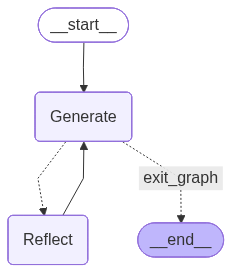

In [17]:
workflow = graph.compile()
workflow

In [18]:
print(workflow.get_graph().draw_mermaid())

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	Generate(Generate)
	Reflect(Reflect)
	__end__([<p>__end__</p>]):::last
	Generate -.-> Reflect;
	Generate -. &nbsp;exit_graph&nbsp; .-> __end__;
	Reflect --> Generate;
	__start__ --> Generate;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



# RUN

In [19]:
query = HumanMessage(content="""
        Write a linkedin post on creating a LinkedIn post agent.
    """
)

In [20]:
# Run agent
inputs = {"messages": [query]}
response = workflow.invoke(inputs)  # All responses

Current Message Count: 2
Latest Draft Preview: To make this post perform well, I’ve structured it...
----------------------------------------------------------------------
Current Message Count: 4
Latest Draft Preview: Great! Since you’ve approved the drafts, here is a...
----------------------------------------------------------------------
Draft approved by critic! Exiting graph.


In [25]:
from IPython.display import display, Markdown
display(Markdown(response["messages"][1].content))

To make this post perform well, I’ve structured it to bridge the gap between "technical implementation" and "value creation." 

Here are three options depending on the "vibe" you want to project:

### Option 1: The "Builder" Approach (Focus on efficiency)
**Best for:** Developers, AI enthusiasts, and productivity geeks.

***

Stop staring at a blank cursor. ✍️

I spent the weekend building a custom AI agent to handle my LinkedIn content creation, and the results have been… game-changing. 

The goal wasn’t to "automate away my personality." It was to automate the heavy lifting so I can focus on the strategy.

**Here’s how the agent works:**
1. **The Context Injection:** I feed it a raw brain dump of my thoughts, a messy transcript, or a rough outline.
2. **The Style Filter:** I’ve trained it on my top 5 performing posts so it mimics my tone, cadence, and formatting preferences.
3. **The Critique Loop:** It reviews its own draft against a set of "engagement principles" (hooks, white space, and clear takeaways) before it hits my inbox.

The result? I’ve cut my content creation time by 70%.

The secret isn’t just "using AI." It’s building a system that understands your voice so well that the "human" part of the process is just the final 10% of editing.

Is AI making you more creative, or just lazier? I’m firmly in the "more creative" camp.

Curious to hear from others building their own agents—what’s the one prompt or tool in your workflow you can’t live without? 👇

#GenerativeAI #LinkedInStrategy #BuildInPublic #ContentCreation #AI

***

### Option 2: The "Thought Leader" Approach (Focus on the future of work)
**Best for:** Consultants, marketers, and solopreneurs.

***

The future of personal branding isn't "writing more." It's "editing better." 

I recently built an AI agent to assist with my LinkedIn content strategy. It’s not a "content generator"—it’s a content *sparring partner.*

Most people use AI to generate generic posts. That’s why your feed is full of "The 5 ways to..." posts that sound like robots wrote them. 

**My approach is different:**
Instead of asking AI to "write a post about X," I built a system that:
*   Refines my unique perspectives.
*   Challenges my logical leaps.
*   Ensures my formatting is readable on mobile.

The AI does the structural work; I provide the soul. 

When you treat AI as an agent rather than a tool, the quality of your output shifts from "average" to "authoritative." 

Are you using AI to replace your thinking, or to amplify your expertise? Let’s discuss in the comments. 🚀

#FutureOfWork #AI #PersonalBranding #ContentStrategy

***

### Option 3: The "Short & Punchy" Approach (Focus on high engagement)
**Best for:** Quick reading and high comment volume.

***

I just built an AI agent that writes my LinkedIn posts for me. 🤖

(Okay, not *for* me—but it does 80% of the work.)

The workflow is simple:
1. Brain dump.
2. Agent structures, formats, and polishes.
3. I add the "human" nuance.

Total time saved: 5+ hours a week. 

The best part? My engagement hasn't dropped—it’s actually gone up. Because the agent forces me to be more concise and hook-driven.

Stop writing from scratch. Start building systems. 🛠️

Want to see the framework I used to build it? Drop a "YES" in the comments and I’ll put together a breakdown.

#Automation #AI #LinkedInGrowth #Efficiency

***

### 3 Tips for Posting:
1. **The Hook:** The first 2 lines are the most important. If you’re posting this on mobile, make sure the "See more" button doesn't cut off your most interesting point.
2. **The Image:** Posts with a screenshot of the agent’s code, the prompt, or a "behind-the-scenes" look at your workflow get significantly higher engagement than text-only posts.
3. **The Timing:** Post between 8:00 AM and 10:30 AM (your target audience's time zone) for maximum reach. 

**Which one would you like to use? If you want to tweak the tone or add specific technical details (like the tool you used, e.g., Make.com, OpenAI API, LangChain), let me know!**